## Problem Statement

### Business Context

Airbnb is an online platform that allows people to rent short-term accommodation. This ranges from regular people with a spare bedroom to property management firms who lease multiple rentals. On the one side, Airbnb enables owners to list their space and earn rental money. On the other side, it provides travelers easy access to renting private homes.

Airbnb receives commissions from two sources upon every booking, namely from the hosts and guests. For every booking, Airbnb charges the guest 6-12% of the booking fee. Moreover, Airbnb charges the host 3% for every successful transaction.

As a senior data scientist at Airbnb, you have to come up with a pricing model that can effectively predict the Rent for accommodation and can help hosts, travelers, and also the business in devising profitable strategies.

### Objective

To explore and visualize the data, build a linear regression model to predict the prices of Airbnb rental rooms, and generate a set of insights and recommendations that will help the business.

### Data Description

The data contains information about the different types of rental rooms offered by Airbnb over a fixed period of time. The detailed data dictionary is given below.

**Data Dictionary**

- id: Property ID
- room_type: Type of Room in the property
- accommodates: How many adults can this property accommodate
- bathrooms: Number of bathrooms on the property
- cancellation_policy: Cancellation policy of the property
- cleaning_fee: This denotes whether the property cleaning fee is included in the rent or not
- instant_bookable: It indicates whether an instant booking facility is available or not
- review_scores_rating: Review rating score of the property
- bedrooms: Number of bedrooms in the property
- beds: Total number of beds in the property
- log_price: Log of the rental price of the property for a fixed period. [If the price is 12000 dollars, then log_price represents log(12000)]

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 29.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## Loading the dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

customer_data = pd.read_csv('/content/drive/MyDrive/Airbnb/Airbnb.csv')

Mounted at /content/drive


## Data Overview

- Observations
- Sanity checks

In [4]:
customer_data.shape

(74111, 11)

*   There are 74111 rows and 11 columns in the given dataset

In [5]:
customer_data.head()

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,6901257,Entire home/apt,3.0,1.0,strict,True,f,100.0,1.0,1.0,5.010635
1,6304928,Entire home/apt,7.0,1.0,strict,True,t,93.0,3.0,3.0,5.129899
2,7919400,Entire home/apt,5.0,1.0,moderate,True,t,92.0,1.0,3.0,4.976734
3,13418779,Entire home/apt,4.0,1.0,flexible,True,f,NaN,2.0,2.0,6.620073
4,3808709,Entire home/apt,2.0,1.0,moderate,True,t,40.0,0.0,1.0,4.744932


In [6]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    74111 non-null  int64  
 1   room_type             74106 non-null  object 
 2   accommodates          74108 non-null  float64
 3   bathrooms             73908 non-null  float64
 4   cancellation_policy   74103 non-null  object 
 5   cleaning_fee          74107 non-null  object 
 6   instant_bookable      74111 non-null  object 
 7   review_scores_rating  57389 non-null  float64
 8   bedrooms              74019 non-null  float64
 9   beds                  73980 non-null  float64
 10  log_price             74111 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 6.2+ MB


*  There are 1 numerical and 5 float columns
*  There are 4 object/categorial columns.

In [7]:
customer_data.isnull().sum()

,0
id,0
room_type,5
accommodates,3
bathrooms,203
cancellation_policy,8
cleaning_fee,4
instant_bookable,0
review_scores_rating,16722
bedrooms,92
beds,131


**Observations:**

*   Some of the columns data is missing in the set
*   Review score rating misses data for 16722 rows.
*   We will try impute the data for missing coulmns after EDA.



In [8]:
customer_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,74111.0,1.126662e+07,6.081735e+06,344.0,6.261964e+06,1.225415e+07,1.640226e+07,2.123090e+07
accommodates,74108.0,3.155125e+00,2.153603e+00,1.0,2.000000e+00,2.000000e+00,4.000000e+00,1.600000e+01
bathrooms,73908.0,1.235272e+00,5.820540e-01,0.0,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
review_scores_rating,57389.0,9.406736e+01,7.836556e+00,20.0,9.200000e+01,9.600000e+01,1.000000e+02,1.000000e+02
bedrooms,74019.0,1.265797e+00,8.521487e-01,0.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01
beds,73980.0,1.710868e+00,1.254142e+00,0.0,1.000000e+00,1.000000e+00,2.000000e+00,1.800000e+01
log_price,74111.0,4.782069e+00,7.173938e-01,0.0,4.317488e+00,4.709530e+00,5.220356e+00,7.600402e+00


**Observations:**

*   Average review ratings is 94
*   Most of the properties are of 1 bed and 1 bath.



**Lets check the unique value in each Categorial Columns**

In [9]:
customer_data['cancellation_policy'].unique()

array(['strict', 'moderate', 'flexible', nan], dtype=object)

In [10]:
customer_data['cleaning_fee'].unique()

array([True, False, nan], dtype=object)

In [11]:
customer_data['instant_bookable'].unique()

array(['f', 't'], dtype=object)

In [12]:
customer_data['room_type'].unique()

array(['Entire home/apt', 'Private room', 'Shared room', nan],
      dtype=object)

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. How are the prices (log_price) of properties distributed?
2. What is the market share of different cancellation policies?
3. How does the price (log_price) of a property vary by the number of bedrooms?
4. How does the price (log_price) of a property vary by the number of accommodates?
5. What are the attributes that have a strong correlation with the price (log_price) of the property?



# Univariate Analysis

In [13]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [14]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

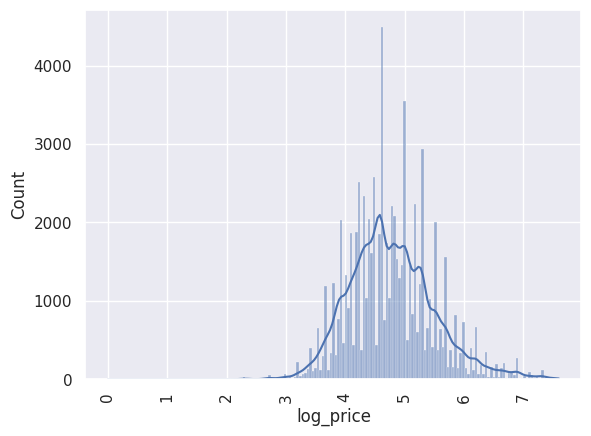

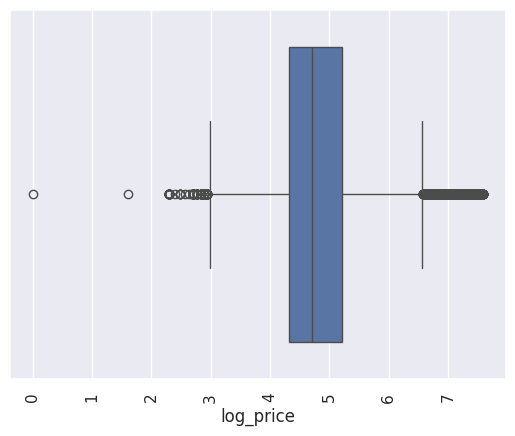

In [15]:
ax = sns.histplot(data =customer_data,x='log_price',kde= True);
ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
plt.show()
x = sns.boxplot(data = customer_data, x ='log_price');
x.set_xticklabels(x.get_xticklabels(), rotation=90);
plt.show()

**Observations:**

*   Log price data is symetrically skewed.
*   There are outliers in the log_price.
*   Average log_price is 4.8





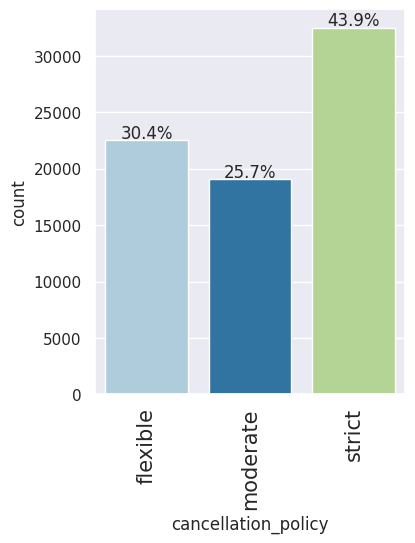

In [16]:
labeled_barplot(customer_data,"cancellation_policy",perc=True)

**Observations**

*   Around 44% of proprety has strict canellation policy.
*   Moderate Policy is the lowest among all cencellation polices.



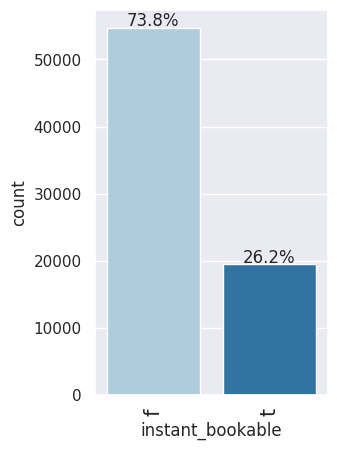

In [17]:
labeled_barplot(customer_data,"instant_bookable",perc=True)

**Observations:**

*  Almost 74% of the property do not allow instant booking.

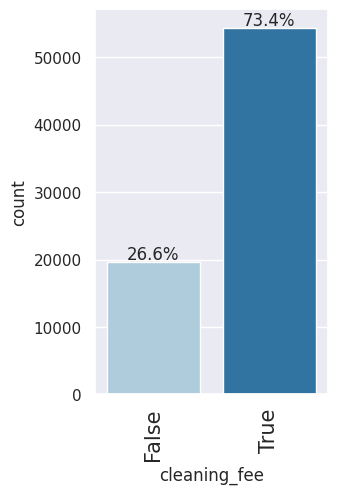

In [18]:
labeled_barplot(customer_data,"cleaning_fee",perc=True)

*  74% of perperty charge the cleaning fee for there properties.

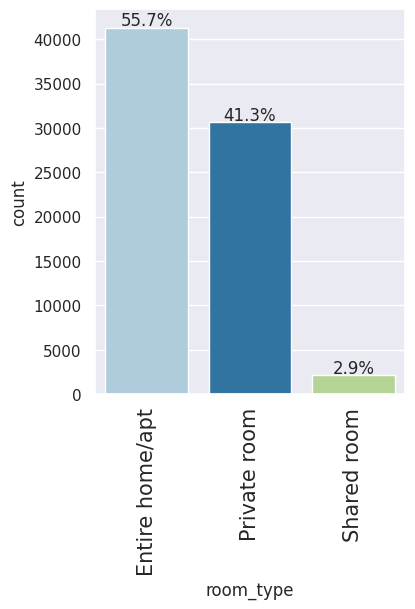

In [19]:
labeled_barplot(customer_data,"room_type",perc=True)

**Observations**

*   55% of proeprties are aor Entire home/apt
*   There very few around 3% are Shared room available.



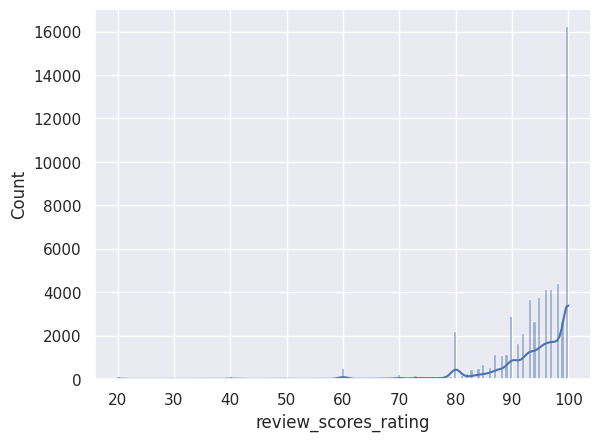

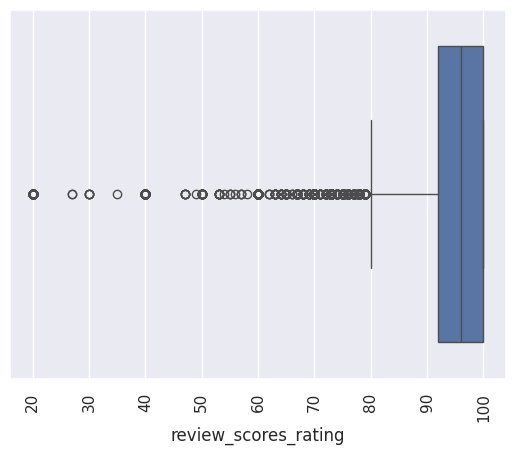

In [20]:
x = sns.histplot(data =customer_data,x='review_scores_rating',kde= True);
ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
plt.show()
x = sns.boxplot(data = customer_data, x ='review_scores_rating');
x.set_xticklabels(x.get_xticklabels(), rotation=90);
plt.show()

*  Review scores rating are highly left skewed.
*  It has lot of outliers in it.

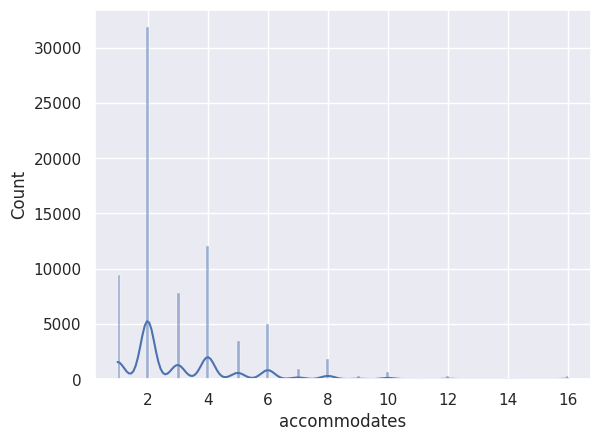

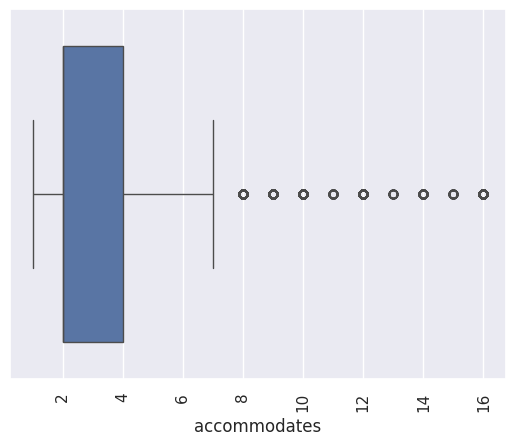

In [21]:
x = sns.histplot(data =customer_data,x='accommodates',kde= True);
ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
plt.show()
x = sns.boxplot(data = customer_data, x ='accommodates');
x.set_xticklabels(x.get_xticklabels(), rotation=90);
plt.show()

**Observations:**

*   Accommodates date looks higly right skewed.
*   Almost 33000 properties whos accommodates 2 guests in there properties, which is highest amoung other.
*   There are outliers and some properties accommodates 16 guests.



# **Bivariate Analysis**

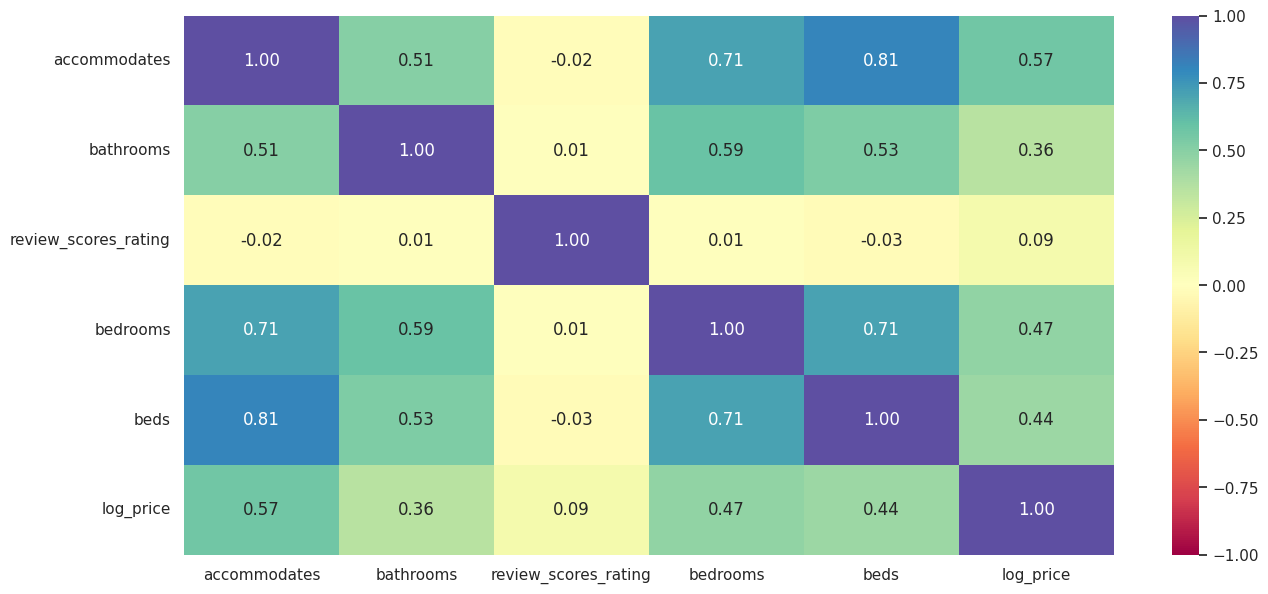

In [22]:
cols_list = customer_data.select_dtypes(include=np.number).columns.tolist()
cols_list.remove('id')
plt.figure(figsize = (15,7))
sns.heatmap(customer_data[cols_list].corr(), annot = True, vmin = -1, vmax =1, fmt = '.2f',cmap="Spectral")
plt.show()

Observations:

*   There is strong correlation between price and accommodates, as accommodates increase price increase.
*   Another positive correlation between price and bedrooms followed by beds. As number of badrooms and bads, the price increases.
we can see strong correlation between price and bathrooms.
*  There are some more strong correlations can be found between beds vs accommodates and bedrooms vs accommodates.
*  There are few negative correlations like review ratings with accommodates and review ratings with beds.

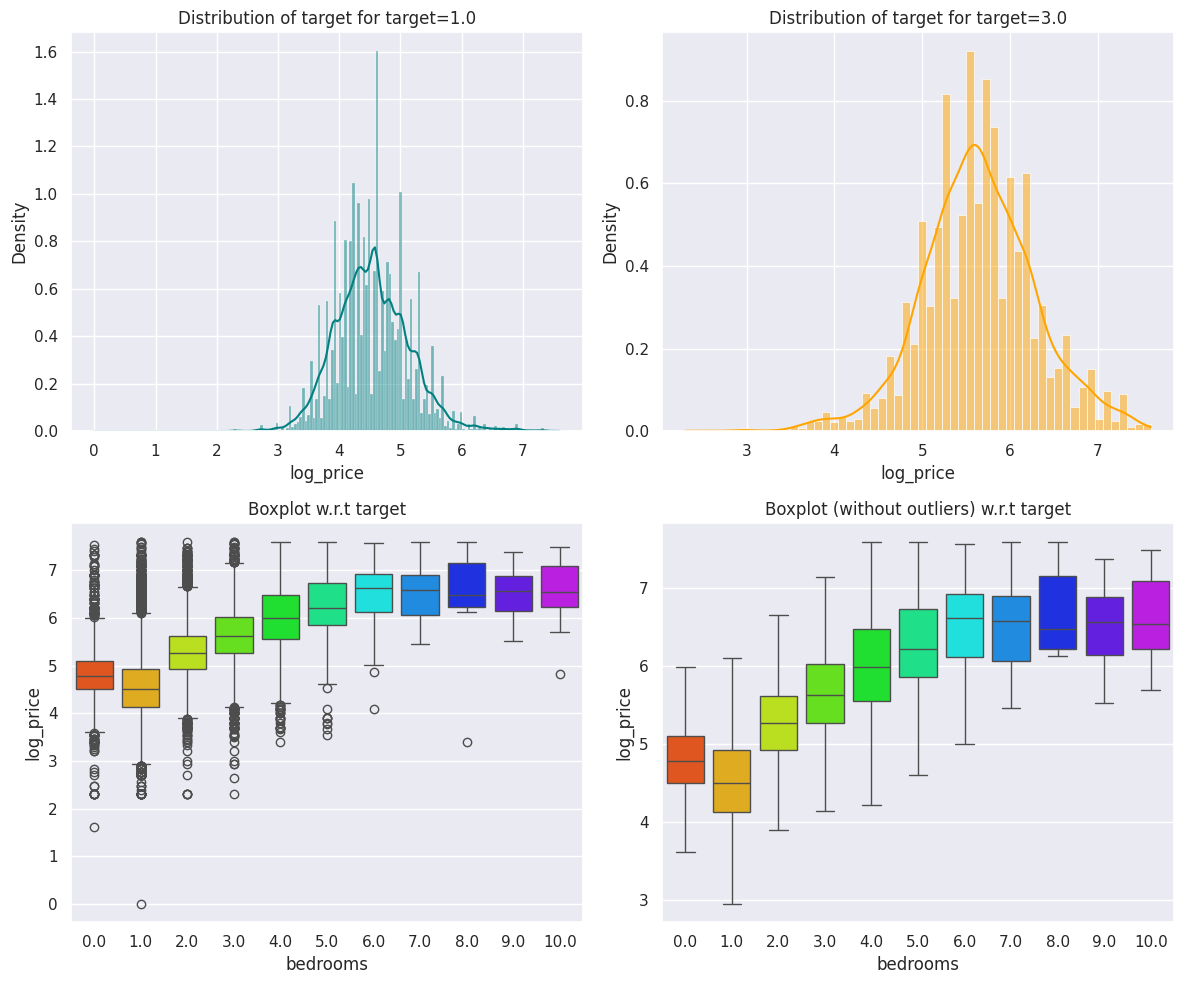

In [23]:
distribution_plot_wrt_target(customer_data,"log_price","bedrooms")

**Observations:**

*   Price is increasing as the number of bedrooms increases.
*   There are outliers for the properties which has less no of bedrooms, outliers decrease as the no of bedroom increase.



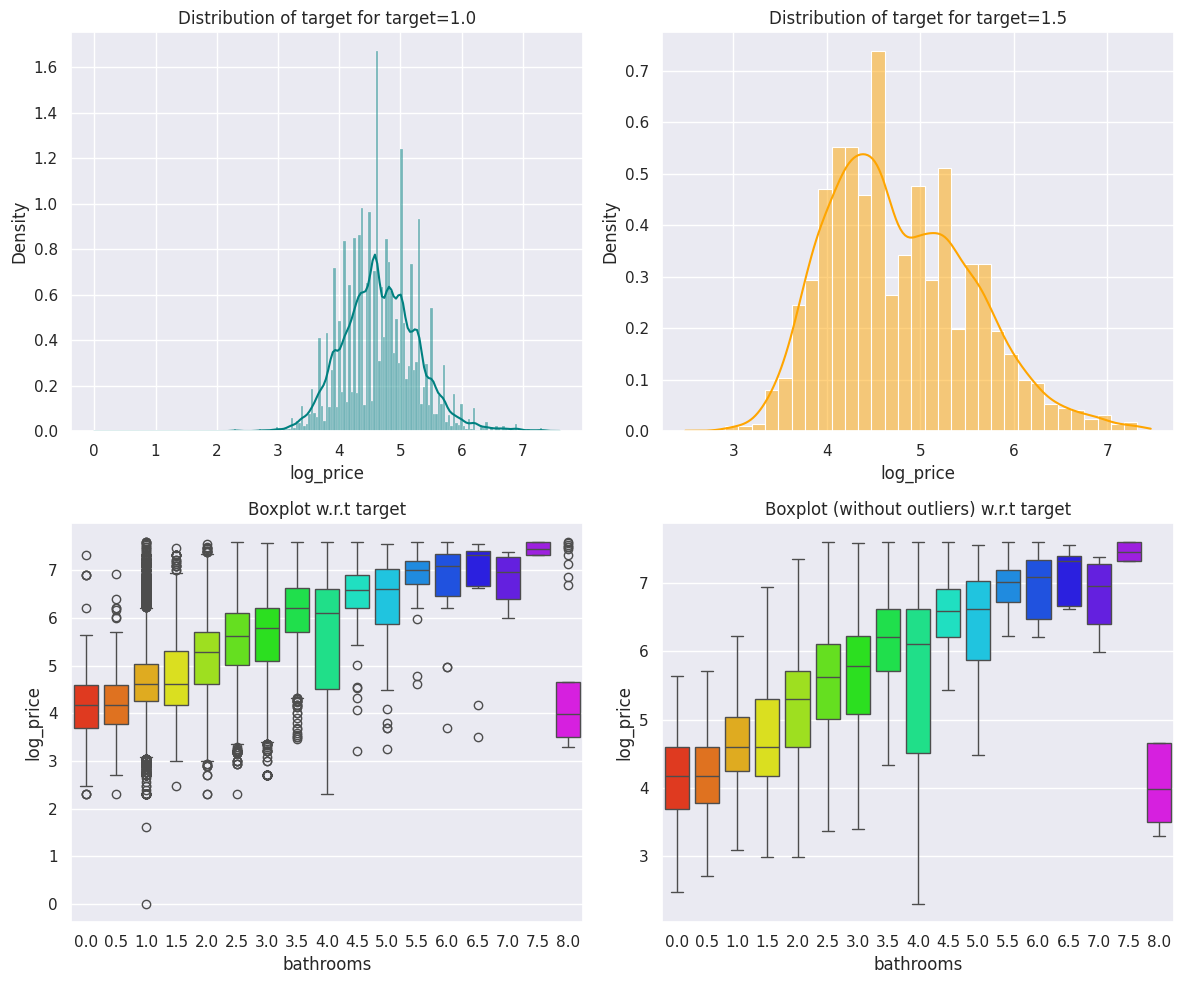

In [24]:
distribution_plot_wrt_target(customer_data,"log_price","bathrooms")

**Observations:**

*   Again the Price increases as the number of bathrooms increases except the property with 8 bathrooms.




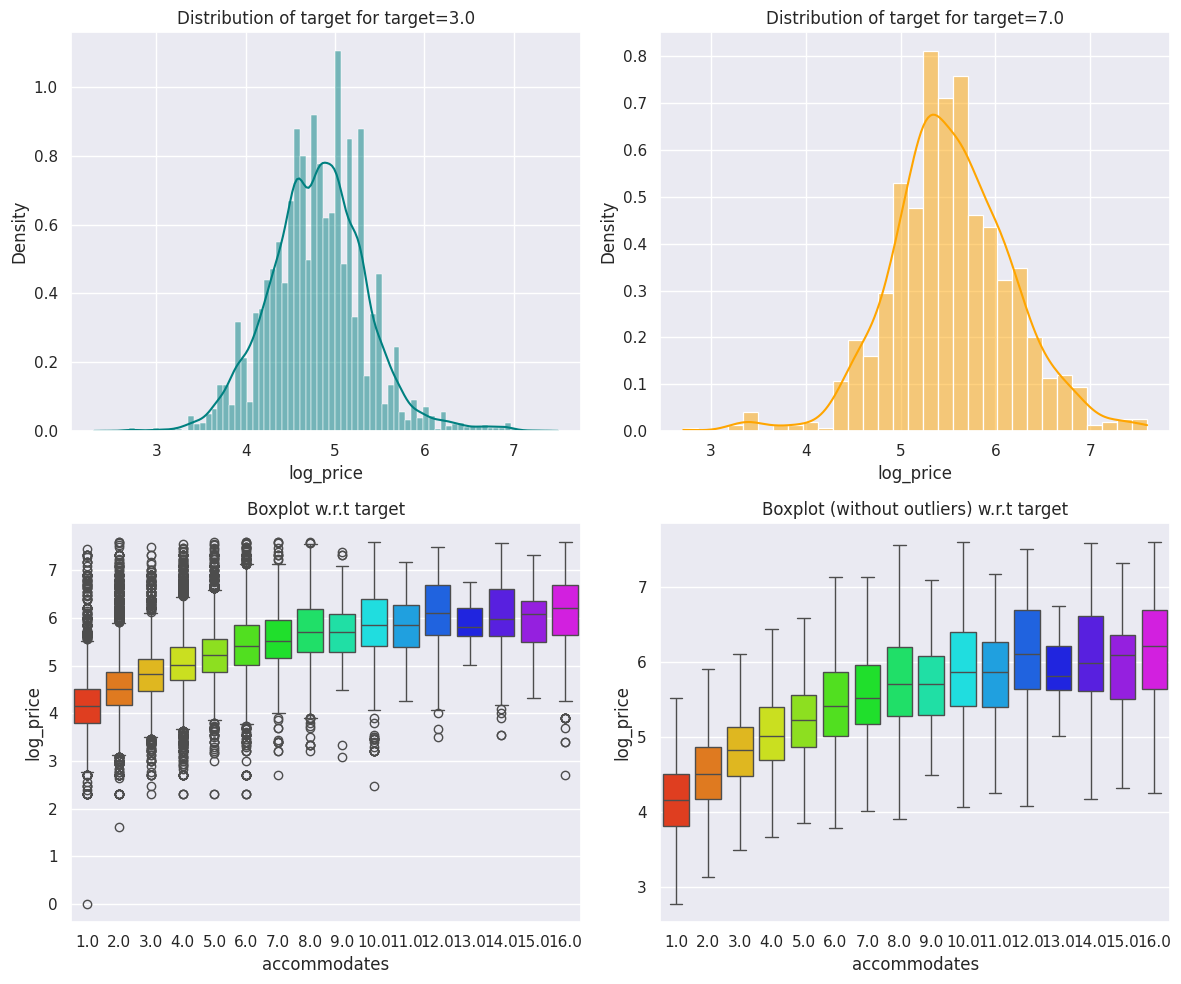

In [25]:
distribution_plot_wrt_target(customer_data,"log_price","accommodates")

**Observations:**

*   Price increase as the no of accommodates increase for the properties.
*   There are outliers for the each perperties accommodates.



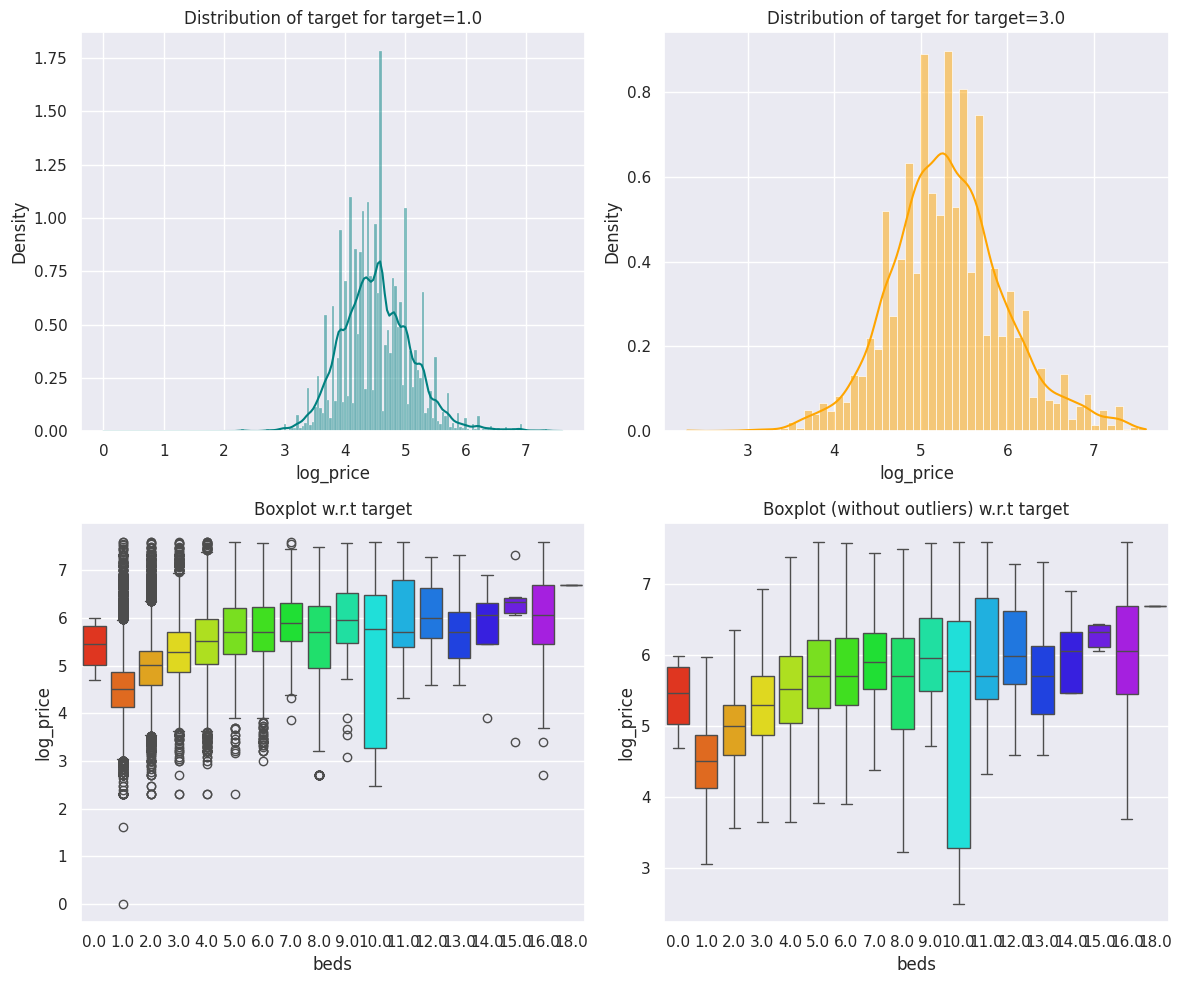

In [26]:
distribution_plot_wrt_target(customer_data,"log_price","beds")

**Observations:**

*   Price increase as the number of beds increases.
*   There are lots of outliers where less number of beds.



## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [27]:
data = customer_data.copy()

In [28]:
data.isnull().sum()

,0
id,0
room_type,5
accommodates,3
bathrooms,203
cancellation_policy,8
cleaning_fee,4
instant_bookable,0
review_scores_rating,16722
bedrooms,92
beds,131




*   There is small number of missing data for room type, accomodates, cancellation_policy, cleaning fee, by deleting it will not lose lot of data.
*   We will treat missing values for bathrooms, bedrooms, review ratings which will contibute in the model buidling.




Lets check if there is any negative review ratings in the data.

In [29]:
data["review_scores_rating"].unique()

array([100.,  93.,  92.,  nan,  40.,  97.,  99.,  90.,  89.,  91.,  88.,
        86.,  72.,  98.,  95.,  96.,  84.,  80.,  94.,  87.,  85.,  70.,
        60.,  75.,  20.,  76.,  83.,  82.,  78.,  73.,  55.,  81.,  67.,
        71.,  77.,  79.,  47.,  74.,  68.,  66.,  63.,  50.,  53.,  65.,
        64.,  27.,  69.,  30.,  58.,  35.,  62.,  49.,  57.,  54.,  56.])

*   There are no negative values in the review ratings. so we can impute the mean to the ratings which are missing in data.

In [30]:
# replace the nan with the mean values of the review ratings.
data["review_scores_rating"].replace(np.nan, data["review_scores_rating"].mean(), inplace=True)


In [31]:
data.isnull().sum()

,0
id,0
room_type,5
accommodates,3
bathrooms,203
cancellation_policy,8
cleaning_fee,4
instant_bookable,0
review_scores_rating,0
bedrooms,92
beds,131


Lets check if there are any outliers in the bathroom, beds & bedrooms to treat.

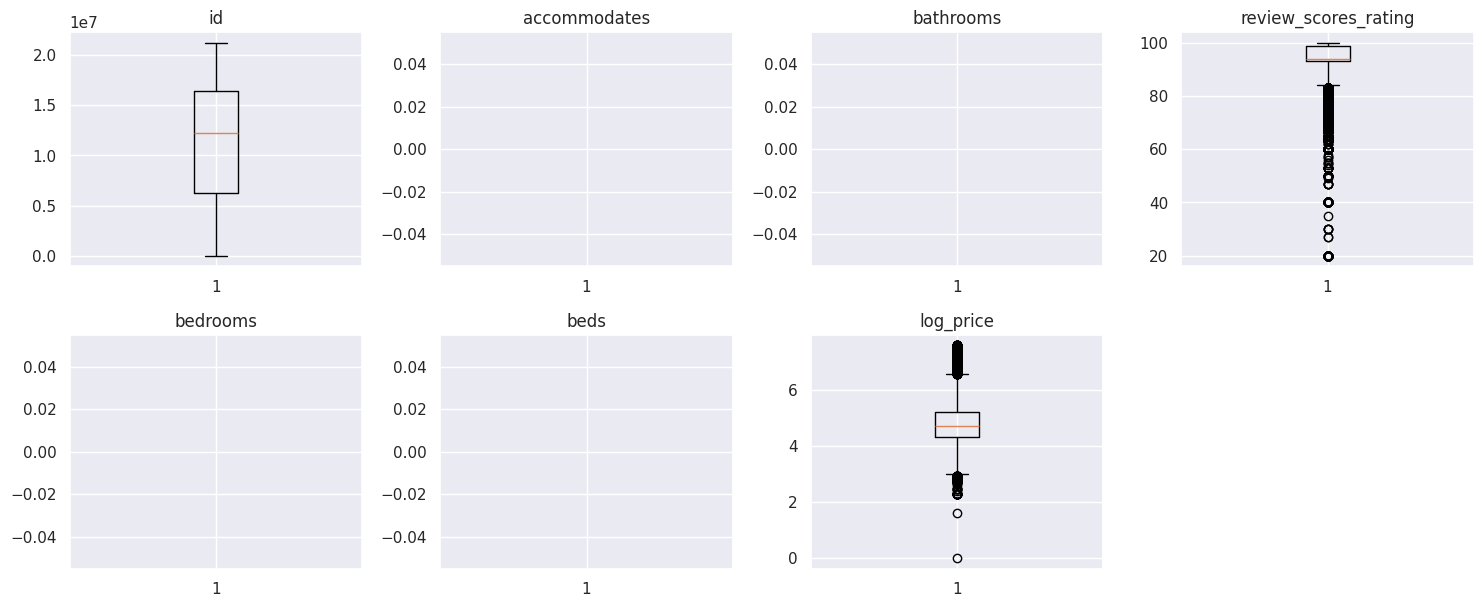

In [32]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Observations:**

*   There are outliers, but all values looks corrects and no need to treate them.





**Lets Impute the data for Bathrooms**

In [33]:
customer_data['bathrooms'].unique()

array([1. , 1.5, 2. , nan, 2.5, 3. , 0.5, 4.5, 5. , 0. , 4. , 3.5, 5.5,
       7.5, 6. , 8. , 7. , 6.5])

In [34]:
data[data["bathrooms"].isnull()]

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
33,10994968,Private room,1.0,NaN,moderate,True,f,99.000000,1.0,1.0,4.488636
38,12232154,Entire home/apt,2.0,NaN,strict,True,f,100.000000,1.0,1.0,4.744932
348,18388570,Entire home/apt,NaN,NaN,NaN,False,f,94.067365,0.0,1.0,4.605170
349,20620600,Private room,NaN,NaN,NaN,True,f,94.067365,1.0,1.0,5.220356
378,13559613,Private room,1.0,NaN,flexible,False,f,94.067365,1.0,NaN,4.605170
...,...,...,...,...,...,...,...,...,...,...,...
72631,3394508,Entire home/apt,2.0,NaN,strict,True,f,98.000000,1.0,1.0,5.521461
73040,13042752,Entire home/apt,4.0,NaN,strict,True,f,92.000000,1.0,1.0,4.595120
73362,19372893,Private room,1.0,NaN,strict,True,f,97.000000,1.0,NaN,4.248495
73377,3157330,Private room,4.0,NaN,strict,True,f,91.000000,1.0,2.0,4.465908


In [35]:
data.groupby(['room_type','bedrooms','beds','accommodates'])['bathrooms'].median().head(50)

room_type        bedrooms  beds  accommodates
Entire home/apt  0.0       0.0   2.0             1.00
                           1.0   1.0             1.00
                                 2.0             1.00
                                 3.0             1.00
                                 4.0             1.00
                                 5.0             1.00
                                 6.0             1.00
                                 7.0             0.75
                                 8.0             1.00
                                 10.0            1.00
                                 16.0            1.00
                           2.0   1.0             1.00
                                 2.0             1.00
                                 3.0             1.00
                                 4.0             1.00
                                 5.0             1.00
                                 6.0             1.00
                                 8.0             2.50
                                 9.0             1.00
                                 10.0            1.00
                                 16.0            1.00
                           3.0   1.0             1.00
                                 2.0             1.00
                                 3.0             1.00
                                 4.0             1.00
                                 5.0             1.00
                                 6.0             1.00
                                 7.0             1.00
                                 8.0             1.00
                           4.0   2.0             1.00
                                 4.0             1.00
                                 5.0             1.00
                                 6.0             1.00
                                 7.0             1.00
                                 8.0             1.00
                                 16.0            1.50
                           5.0   5.0             2.00
                                 6.0             1.00
                           6.0   12.0            1.00
                           8.0   2.0             4.00
                                 8.0             1.00
                                 10.0            1.00
                           16.0  16.0            1.00
                 1.0       0.0   2.0             1.00
                                 4.0             1.00
                           1.0   1.0             1.00
                                 2.0             1.00
                                 3.0             1.00
                                 4.0             1.00
                                 5.0             1.00
Name: bathrooms, dtype: float64

In [36]:
data['bathrooms'] = data['bathrooms'].fillna(data.groupby(['room_type','bedrooms','beds','accommodates']).bathrooms.transform('median'))

In [37]:
data.shape

(74111, 11)

In [38]:
data.isnull().sum()

,0
id,0
room_type,5
accommodates,3
bathrooms,51
cancellation_policy,8
cleaning_fee,4
instant_bookable,0
review_scores_rating,0
bedrooms,92
beds,131


In [39]:
data[data["bathrooms"].isnull()]

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
348,18388570,Entire home/apt,NaN,NaN,NaN,False,f,94.067365,0.0,1.0,4.605170
349,20620600,Private room,NaN,NaN,NaN,True,f,94.067365,1.0,1.0,5.220356
378,13559613,Private room,1.0,NaN,flexible,False,f,94.067365,1.0,NaN,4.605170
454,7939196,Entire home/apt,NaN,NaN,NaN,True,f,82.000000,1.0,3.0,4.867534
1824,11084417,Private room,1.0,NaN,flexible,False,f,94.067365,1.0,NaN,5.298317
2368,19360685,Entire home/apt,2.0,NaN,flexible,False,f,94.067365,NaN,NaN,5.262690
2842,12130093,Entire home/apt,2.0,NaN,moderate,False,f,91.000000,NaN,1.0,4.382027
3150,4280150,Private room,1.0,NaN,moderate,True,f,94.067365,1.0,NaN,4.605170
4631,20619286,Private room,2.0,NaN,moderate,True,f,94.067365,1.0,NaN,4.382027
4757,7181688,Shared room,1.0,NaN,strict,False,f,96.000000,1.0,NaN,3.367296


In [40]:
data['bathrooms'] = data['bathrooms'].fillna(data.groupby(['room_type','bedrooms','beds']).bathrooms.transform('median'))

In [41]:
data['bathrooms'] = data['bathrooms'].fillna(data.groupby(['room_type','bedrooms','accommodates']).bathrooms.transform('median'))

In [42]:
data['bathrooms'] = data['bathrooms'].fillna(data.groupby(['room_type','beds','accommodates']).bathrooms.transform('median'))

In [43]:
data['bathrooms'] = data['bathrooms'].fillna(data.groupby(['room_type','accommodates']).bathrooms.transform('median'))

* Now we have imputed the data based on the median of the other columns such as bedrooms, beds, accommodates.

**Lets check if we can able to impute the data for bedrooms**

In [44]:
data.isnull().sum()

,0
id,0
room_type,5
accommodates,3
bathrooms,0
cancellation_policy,8
cleaning_fee,4
instant_bookable,0
review_scores_rating,0
bedrooms,92
beds,131


In [45]:
data[data['bedrooms'].isnull()]

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
200,7575345,Entire home/apt,2.0,1.0,strict,True,f,89.000000,NaN,1.0,5.433722
301,17109866,Entire home/apt,1.0,1.0,flexible,False,f,94.067365,NaN,NaN,4.248495
376,9862763,Private room,1.0,1.0,strict,True,t,80.000000,NaN,1.0,3.688879
2368,19360685,Entire home/apt,2.0,1.0,flexible,False,f,94.067365,NaN,NaN,5.262690
2842,12130093,Entire home/apt,2.0,1.0,moderate,False,f,91.000000,NaN,1.0,4.382027
3331,8934887,Entire home/apt,2.0,1.0,moderate,False,f,100.000000,NaN,1.0,4.532599
6647,18109744,Entire home/apt,2.0,1.0,strict,False,f,94.000000,NaN,1.0,4.584967
7155,150591,Entire home/apt,2.0,1.0,strict,False,f,78.000000,NaN,1.0,5.342334
8807,808476,Entire home/apt,2.0,1.0,strict,True,f,94.000000,NaN,1.0,4.605170
10513,18750597,Entire home/apt,4.0,1.0,moderate,True,f,93.000000,NaN,1.0,4.369448


In [46]:
data['bedrooms'] = data['bedrooms'].fillna(data.groupby(['room_type','bathrooms','beds','accommodates']).bathrooms.transform('median'))

In [47]:
data['bedrooms'] = data['bedrooms'].fillna(data.groupby(['room_type','bathrooms','accommodates']).bathrooms.transform('median'))

In [48]:
data['beds'] = data['beds'].fillna(data.groupby(['room_type','bathrooms','bedrooms','accommodates']).bathrooms.transform('median'))

In [49]:
# delete the rows for room_type, accommodates, cancellation Policy & Cleaning fee where there is no data available.
data = data.dropna(subset=['room_type','accommodates','cancellation_policy','cleaning_fee'])

In [50]:
data.isnull().sum()

,0
id,0
room_type,0
accommodates,0
bathrooms,0
cancellation_policy,0
cleaning_fee,0
instant_bookable,0
review_scores_rating,0
bedrooms,0
beds,0


*   All missing values are dealt with.

In [51]:
data.shape

(74098, 11)

*   Now we treated the null values in the data, there are no values missings in the data.

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74098 entries, 0 to 74110
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    74098 non-null  int64  
 1   room_type             74098 non-null  object 
 2   accommodates          74098 non-null  float64
 3   bathrooms             74098 non-null  float64
 4   cancellation_policy   74098 non-null  object 
 5   cleaning_fee          74098 non-null  object 
 6   instant_bookable      74098 non-null  object 
 7   review_scores_rating  74098 non-null  float64
 8   bedrooms              74098 non-null  float64
 9   beds                  74098 non-null  float64
 10  log_price             74098 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 6.8+ MB


Lets check the unique values for bathrooms, beds & accomodates to see if we can change the data type from float to int

In [53]:
data["bathrooms"].unique()

array([1. , 1.5, 2. , 2.5, 3. , 0.5, 4.5, 5. , 0. , 4. , 3.5, 5.5, 7.5,
       6. , 8. , 7. , 6.5])

In [54]:
data["bedrooms"].unique()

array([ 1. ,  3. ,  2. ,  0. ,  4. ,  5. ,  6. ,  7. ,  8. ,  9. , 10. ,
        1.5])

In [55]:
data["beds"].unique()

array([ 1. ,  3. ,  2. ,  7. ,  4. ,  6. ,  5. , 10. ,  8. , 16. ,  9. ,
       13. , 12. , 11. , 14. , 15. ,  0. ,  2.5,  1.5, 18. ])

In [56]:
data["accommodates"].unique()

array([ 3.,  7.,  5.,  4.,  2.,  6.,  8.,  1.,  9., 10., 16., 11., 12.,
       14., 13., 15.])

In [57]:
data["beds"] = data["beds"].astype("int64")
data["bedrooms"] = data["bedrooms"].astype("int64")
data["accommodates"] = data["accommodates"].astype("int64")
data['cancellation_policy'] = data['cancellation_policy'].astype('category')
data['room_type'] = data['room_type'].astype('category')


*   Corrected the data types of other columns
*   Bedrooms cannot be float so converted them to int.

## Model Building - Linear Regression



1.   We want to predict the log price for the property.
2.   Before we proceed to build a model, we'll have to encode categorical features.
3.   We'll split the data into train and test to be able to evaluate the model that we build on the train data.
4.   We will build a Linear Regression model using the train data and then check it's performance.





In [58]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
        },
        index=[0],
    )

    return df_perf

In [59]:
# looking at value counts for non-numeric features

num_to_display = 10  # defining this up here so it's easy to change later

for colname in data.dtypes[data.dtypes == "object"].index:
    val_counts = data[colname].value_counts(dropna=False)  # will also show the NA counts
    print(val_counts[:num_to_display])

    if len(val_counts) > num_to_display:
        print(f"Only displaying first {num_to_display} of {len(val_counts)} values.")
    print("-" * 50, "\n")  # just for more space in between

cleaning_fee
True     54393
False    19705
Name: count, dtype: int64
-------------------------------------------------- 

instant_bookable
f    54650
t    19448
Name: count, dtype: int64
-------------------------------------------------- 



Cleaning fee has boolean values, we can convert those to int which will assign 1 for True and 0 for false.

In [60]:
data["cleaning_fee"] = data["cleaning_fee"].astype(int)

In [61]:
data["cleaning_fee"].unique()

array([1, 0])

In [62]:
data.head()

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,6901257,Entire home/apt,3,1.0,strict,1,f,100.000000,1,1,5.010635
1,6304928,Entire home/apt,7,1.0,strict,1,t,93.000000,3,3,5.129899
2,7919400,Entire home/apt,5,1.0,moderate,1,t,92.000000,1,3,4.976734
3,13418779,Entire home/apt,4,1.0,flexible,1,f,94.067365,2,2,6.620073
4,3808709,Entire home/apt,2,1.0,moderate,1,t,40.000000,0,1,4.744932


Lets map the instant bookable values to t as 1 & f as 0

In [63]:
mapping = {'f' : 0, 't' : 1}
data['instant_bookable'] = data['instant_bookable'].map(mapping)

In [64]:
data["instant_bookable"].unique()

array([0, 1])

Lets drop the id column which is continues variable and won't be useful in our model building

In [65]:
data.drop("id",axis = 1, inplace = True)

In [66]:
data.head()

,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,Entire home/apt,3,1.0,strict,1,0,100.000000,1,1,5.010635
1,Entire home/apt,7,1.0,strict,1,1,93.000000,3,3,5.129899
2,Entire home/apt,5,1.0,moderate,1,1,92.000000,1,3,4.976734
3,Entire home/apt,4,1.0,flexible,1,0,94.067365,2,2,6.620073
4,Entire home/apt,2,1.0,moderate,1,1,40.000000,0,1,4.744932


In [67]:
df = data.copy()

# **Data Preparation for modeling with all variables**

In [68]:
X = df.drop("log_price",axis = 1)
y = df["log_price"]


X=pd.get_dummies(X, drop_first = True)
X.head()

# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)


In [69]:
x_train.head()

,accommodates,bathrooms,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,room_type_Private room,room_type_Shared room,cancellation_policy_moderate,cancellation_policy_strict
4031,1,2.0,0,0,60.000000,1,1,True,False,False,False
891,2,2.0,1,0,94.067365,1,1,True,False,False,True
15573,2,1.0,1,0,100.000000,1,1,False,False,True,False
63820,2,1.0,1,0,99.000000,1,1,True,False,False,True
20054,2,1.0,0,0,94.067365,1,1,False,False,False,False


In [70]:
x_train.shape

(51868, 11)

# **Model Building - Linear Regression with all variables**

In [71]:
# fitting a linear model
lin_reg_model = LinearRegression()
lin_reg_model.fit(x_train, y_train)

LinearRegression()

In [72]:
# Checking model performance on train set
print("Training Performance:")
lin_reg_model_perf_train = model_performance_regression(
    lin_reg_model, x_train, y_train
)
lin_reg_model_perf_train

Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,0.497216,0.377457,0.518316,0.518214


In [73]:
# Checking model performance on test set
print("Test Performance:")
lin_reg_model_perf_test = model_performance_regression(lin_reg_model, x_test, y_test)
lin_reg_model_perf_test

Test Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,0.50114,0.379193,0.515176,0.514936


**Observations:**

*   The training data performance and the test data performance are very similar, that means the model is well genaralize.
*   But the R-Square and adj R-Square scores for both training and test are low.



# **Data Preparation for modeling without dummy variables for Model**

In [74]:
X = df.drop(["log_price",'room_type','cancellation_policy'],axis = 1)
y = df["log_price"]


# splitting the data in 70:30 ratio for train to test data

x_train2, x_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.3, random_state=1
)


In [75]:
x_train.head()

,accommodates,bathrooms,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,room_type_Private room,room_type_Shared room,cancellation_policy_moderate,cancellation_policy_strict
4031,1,2.0,0,0,60.000000,1,1,True,False,False,False
891,2,2.0,1,0,94.067365,1,1,True,False,False,True
15573,2,1.0,1,0,100.000000,1,1,False,False,True,False
63820,2,1.0,1,0,99.000000,1,1,True,False,False,True
20054,2,1.0,0,0,94.067365,1,1,False,False,False,False


# **Model Building - Linear Regression without dummy variables for Model**

In [76]:
# fitting a linear model
lin_reg_model2 = LinearRegression()
lin_reg_model2.fit(x_train2, y_train)

LinearRegression()

In [77]:
# Checking model performance on train set
print("Training Performance:")
lin_reg_model2_perf_train = model_performance_regression(
    lin_reg_model2, x_train2, y_train
)
lin_reg_model2_perf_train

Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,0.578572,0.444783,0.347791,0.347703


In [78]:
# Checking model performance on test set
print("Test Performance:")
lin_reg_model2_perf_test = model_performance_regression(lin_reg_model2, x_test2, y_test)
lin_reg_model2_perf_test

Test Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,0.578977,0.444218,0.352873,0.352669


## Model Performance Check

In [79]:
# training performance comparison

models_train_comp_df = pd.concat(
    [lin_reg_model_perf_train.T, lin_reg_model2_perf_train.T,], axis=1,
)

models_train_comp_df.columns = [
    "Linear Regression (all variables)",
    "Linear Regression (without dummy variables for Model)",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Linear Regression (all variables),Linear Regression (without dummy variables for Model)
RMSE,0.497216,0.578572
MAE,0.377457,0.444783
R-squared,0.518316,0.347791
Adj. R-squared,0.518214,0.347703


**Observation:**

*   The model with all the variables has the good R-Squared score compare to model without dummy variable.
*   So will choose the model with all the vairable as our final model.



In [80]:
# training performance comparison

models_train_comp_df = pd.concat(
    [lin_reg_model_perf_train.T,lin_reg_model_perf_test.T], axis=1,
)

models_train_comp_df.columns = [
    "Linear Regression Training",
    "Linear Regression Test",
]

print("performance comparison:")
models_train_comp_df

performance comparison:


,Linear Regression Training,Linear Regression Test
RMSE,0.497216,0.501140
MAE,0.377457,0.379193
R-squared,0.518316,0.515176
Adj. R-squared,0.518214,0.514936


## Actionable Insights and Recommendations

*   Our linear regression model has successfully explained approximately 51% of the variation in the data.
*   Our analysis has revealed that certain factors, total number people that property can accommodate, number of bedroom, number of bathroom and number of beds in the property, tend to increase the price.
*   It is benefical for Airbnb to focus on the big properties which can accommodate more people and has more number of bedroom, bathroom and beds to increase the business and profits.




___